<a href="https://colab.research.google.com/github/dawoodahmadbakhsh21-web/-house-price-prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# Install all required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn fpdf2 ipywidgets -q

# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                               classification_report, roc_auc_score,
                               roc_curve, f1_score)

# Interactive UI & PDF
import ipywidgets as widgets
from IPython.display import display
from fpdf import FPDF
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [22]:
import os

# Paste your Kaggle credentials here from kaggle.json
os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'  # ← change this
os.environ['KAGGLE_KEY']      = 'YOUR_KAGGLE_API_KEY'   # ← change this

# Install kaggle library
!pip install kaggle -q

# Download the Telco Customer Churn dataset
!kaggle datasets download -d blastchar/telco-customer-churn --unzip

print("Dataset downloaded successfully!")
print("Files available:")
!ls *.csv

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 32.2MB/s]

Dataset downloaded successfully!
Files available:
WA_Fn-UseC_-Telco-Customer-Churn.csv


In [23]:
# Load the downloaded CSV file
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Basic overview
print("=== Dataset Overview ===")
print(f"Total customers : {len(df):,}")
print(f"Total columns   : {df.shape[1]}")

# Churn distribution
churn_counts = df['Churn'].value_counts()
churn_rate   = df['Churn'].value_counts(normalize=True) * 100

print(f"\n=== Churn Distribution ===")
print(f"Stayed  : {churn_counts['No']:,}  ({churn_rate['No']:.1f}%)")
print(f"Churned : {churn_counts['Yes']:,}  ({churn_rate['Yes']:.1f}%)")
print("\nDataset loaded successfully!")

=== Dataset Overview ===
Total customers : 7,043
Total columns   : 21

=== Churn Distribution ===
Stayed  : 5,174  (73.5%)
Churned : 1,869  (26.5%)

Dataset loaded successfully!


In [24]:
# Preview first 5 rows
print("=== First 5 rows ===")
display(df.head())

# Column descriptions
print("\n=== Column Descriptions ===")
col_info = {
    'customerID':      'Unique customer ID',
    'gender':           'Male or Female',
    'SeniorCitizen':    'Is senior citizen (0/1)',
    'Partner':          'Has a partner (Yes/No)',
    'Dependents':       'Has dependents (Yes/No)',
    'tenure':           'Months with the company',
    'InternetService':  'DSL / Fiber optic / No',
    'Contract':         'Month-to-month / One year / Two year',
    'MonthlyCharges':   'Monthly bill in USD',
    'TotalCharges':     'Total amount paid (fix needed in Step 2)',
    'Churn':            'Left the company? Yes/No  ← PREDICT THIS',
}
for col, desc in col_info.items():
    print(f"  {col:20} → {desc}")

# Missing values check
print("\n=== Missing Values ===")
print(df.isnull().sum().sort_values(ascending=False).head())

print("\nStep 1 complete! Ready to move to Step 2.")

=== First 5 rows ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



=== Column Descriptions ===
  customerID           → Unique customer ID
  gender               → Male or Female
  SeniorCitizen        → Is senior citizen (0/1)
  Partner              → Has a partner (Yes/No)
  Dependents           → Has dependents (Yes/No)
  tenure               → Months with the company
  InternetService      → DSL / Fiber optic / No
  Contract             → Month-to-month / One year / Two year
  MonthlyCharges       → Monthly bill in USD
  TotalCharges         → Total amount paid (fix needed in Step 2)
  Churn                → Left the company? Yes/No  ← PREDICT THIS

=== Missing Values ===
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

Step 1 complete! Ready to move to Step 2.


In [25]:
# ── DATA CLEANING ──────────────────────────────────────────

# Drop customerID — not useful for prediction
df = df.drop(columns=['customerID'])

# Fix TotalCharges — it's a string, convert to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert target column — Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Label encode all other categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Keep a copy of original for EDA plots
df_original = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_original['TotalCharges'] = pd.to_numeric(
    df_original['TotalCharges'], errors='coerce')
df_original.dropna(inplace=True)

print("=== Cleaning Summary ===")
print(f"Shape after cleaning : {df.shape}")
print(f"Missing values left  : {df.isnull().sum().sum()}")
print(f"Categorical cols encoded : {list(cat_cols)}")
print("\nData cleaning complete!")

=== Cleaning Summary ===
Shape after cleaning : (7043, 20)
Missing values left  : 0
Categorical cols encoded : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Data cleaning complete!


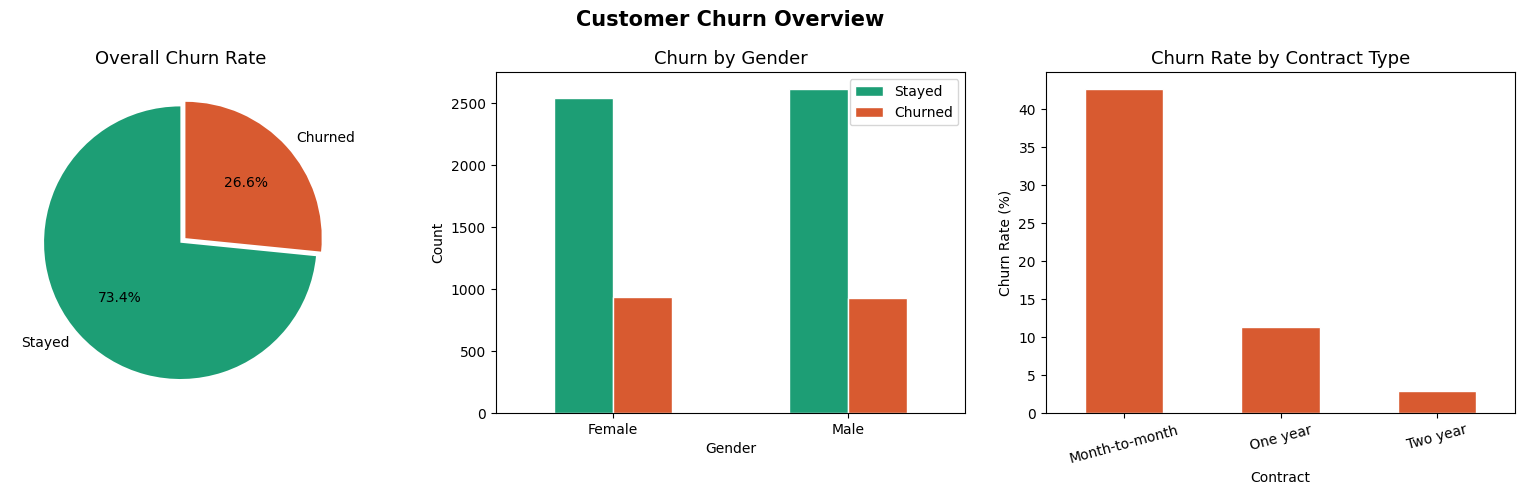

Saved: plot_churn_overview.png


In [26]:
# ── PLOT 1: Churn Overview ─────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart — churn ratio
churn_counts = df_original['Churn'].value_counts()
axes[0].pie(
    churn_counts,
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%',
    colors=['#1D9E75', '#D85A30'],
    startangle=90,
    explode=(0, 0.05)
)
axes[0].set_title('Overall Churn Rate', fontsize=13)

# Churn by gender
gender_churn = df_original.groupby('gender')['Churn'].value_counts().unstack()
gender_churn.plot(kind='bar', ax=axes[1],
                  color=['#1D9E75', '#D85A30'],
                  edgecolor='white', rot=0)
axes[1].set_title('Churn by Gender', fontsize=13)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].legend(['Stayed', 'Churned'])

# Churn by contract type
contract_churn = df_original.groupby('Contract')['Churn'].value_counts(normalize=True).\
    unstack()['Yes'] * 100
contract_churn.plot(kind='bar', ax=axes[2],
                    color='#D85A30', edgecolor='white', rot=15)
axes[2].set_title('Churn Rate by Contract Type', fontsize=13)
axes[2].set_xlabel('Contract')
axes[2].set_ylabel('Churn Rate (%)')

plt.suptitle('Customer Churn Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_churn_overview.png")

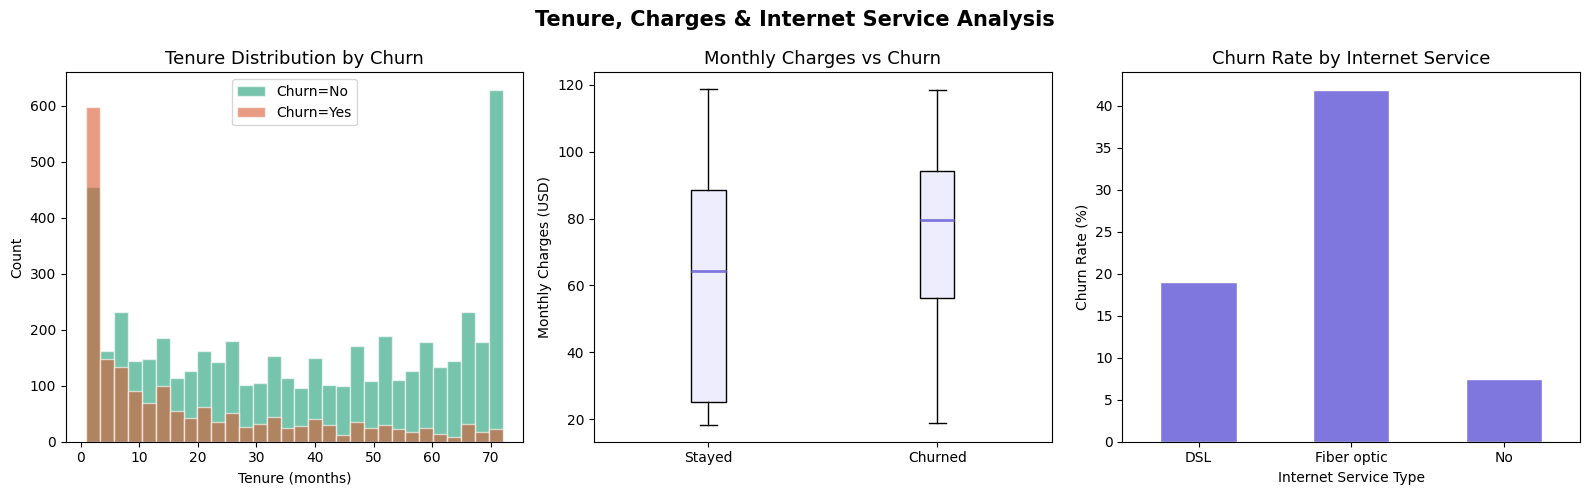

Saved: plot_tenure_charges.png


In [27]:
# ── PLOT 2: Tenure & Charges ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tenure distribution by churn
for label, color in [('No', '#1D9E75'), ('Yes', '#D85A30')]:
    subset = df_original[df_original['Churn'] == label]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.6,
                color=color, label=f'Churn={label}', edgecolor='white')
axes[0].set_title('Tenure Distribution by Churn', fontsize=13)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Monthly charges box plot
churn_yes = df_original[df_original['Churn']=='Yes']['MonthlyCharges']
churn_no  = df_original[df_original['Churn']=='No']['MonthlyCharges']
axes[1].boxplot([churn_no, churn_yes],
               labels=['Stayed', 'Churned'],
               patch_artist=True,
               boxprops=dict(facecolor='#EEEDFE'),
               medianprops=dict(color='#7F77DD', linewidth=2))
axes[1].set_title('Monthly Charges vs Churn', fontsize=13)
axes[1].set_ylabel('Monthly Charges (USD)')

# Internet service churn rate
internet_churn = df_original.groupby('InternetService')['Churn'].\
    value_counts(normalize=True).unstack()['Yes'] * 100
internet_churn.plot(kind='bar', ax=axes[2],
                    color='#7F77DD', edgecolor='white', rot=0)
axes[2].set_title('Churn Rate by Internet Service', fontsize=13)
axes[2].set_xlabel('Internet Service Type')
axes[2].set_ylabel('Churn Rate (%)')

plt.suptitle('Tenure, Charges & Internet Service Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_tenure_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_tenure_charges.png")

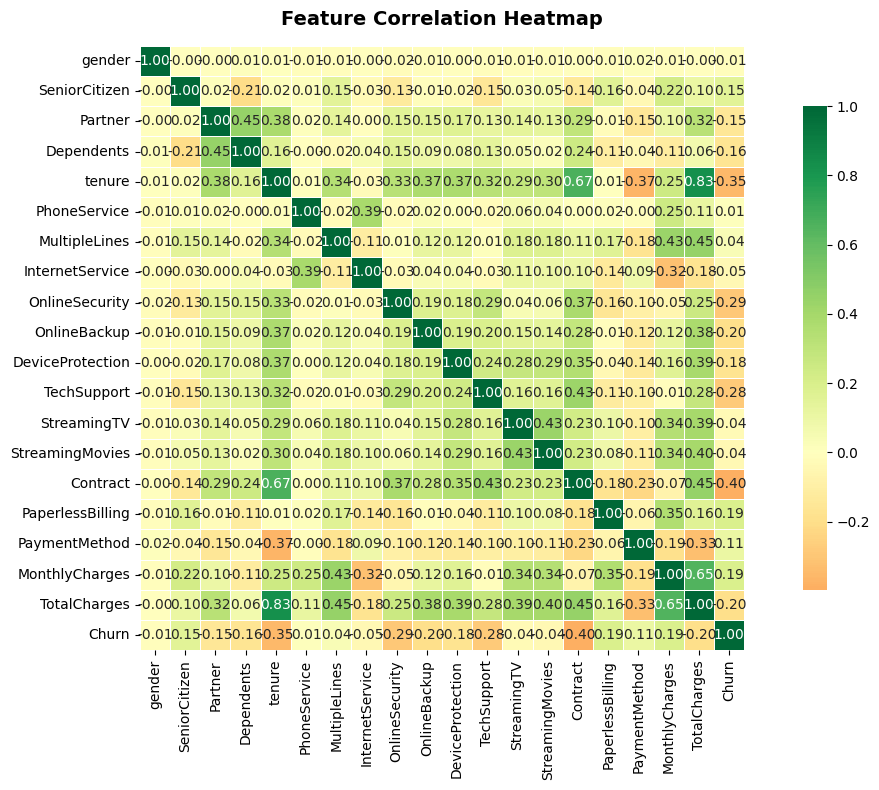

=== Top features correlated with Churn ===
  Contract             0.397  ███████████
  tenure               0.352  ██████████
  OnlineSecurity       0.289  ████████
  TechSupport          0.282  ████████
  TotalCharges         0.199  █████
  OnlineBackup         0.196  █████
  MonthlyCharges       0.193  █████
  PaperlessBilling     0.192  █████
  DeviceProtection     0.178  █████
  Dependents           0.164  ████
  SeniorCitizen        0.151  ████
  Partner              0.150  ████
  PaymentMethod        0.107  ███
  InternetService      0.047  █
  StreamingMovies      0.038  █
  MultipleLines        0.038  █
  StreamingTV          0.037  █
  PhoneService         0.012  
  gender               0.009  

Saved: plot_heatmap.png


In [28]:
# ── PLOT 3: Correlation Heatmap ────────────────────────────

plt.figure(figsize=(12, 8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Feature Correlation Heatmap', fontsize=14,
         fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top features correlated with Churn
print("=== Top features correlated with Churn ===")
churn_corr = corr['Churn'].drop('Churn').abs().\
    sort_values(ascending=False)
for feat, val in churn_corr.items():
    bar = "█" * int(val * 30)
    print(f"  {feat:20} {val:.3f}  {bar}")
print("\nSaved: plot_heatmap.png")

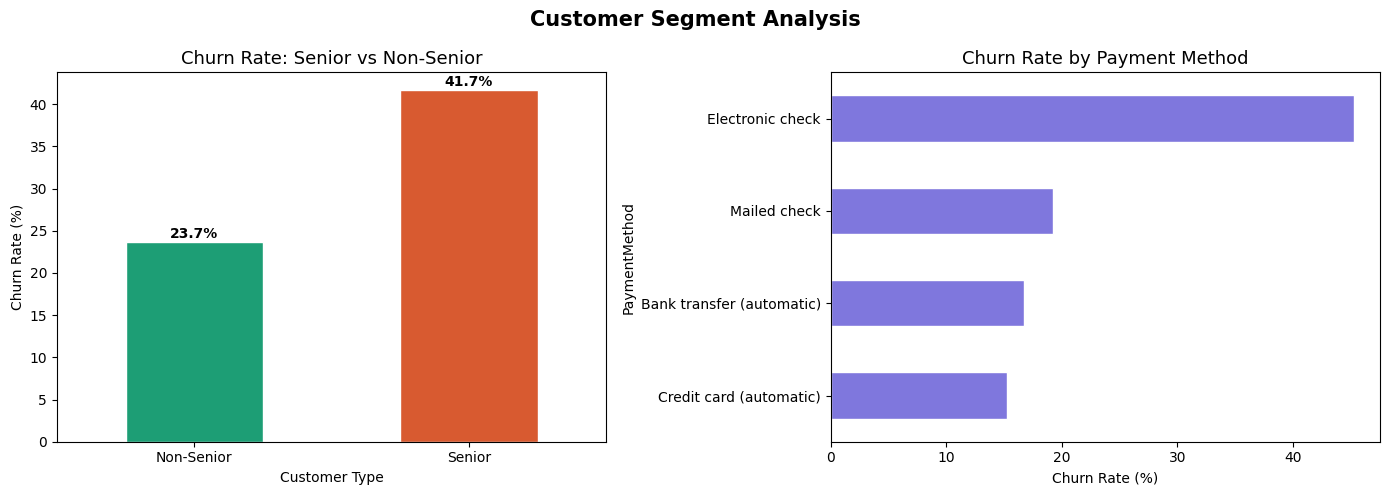

Saved: plot_segments.png

=== Step 2 Complete! ===
Plots saved: churn overview, tenure/charges, heatmap, segments
Ready to move to Step 3 — Model Training


In [29]:
# ── PLOT 4: Senior Citizen & Payment Analysis ──────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Senior citizen churn comparison
senior_churn = df_original.groupby('SeniorCitizen')['Churn'].\
    value_counts(normalize=True).unstack()['Yes'] * 100
senior_churn.index = ['Non-Senior', 'Senior']
senior_churn.plot(kind='bar', ax=axes[0],
                  color=['#1D9E75', '#D85A30'],
                  edgecolor='white', rot=0, width=0.5)
axes[0].set_title('Churn Rate: Senior vs Non-Senior', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Customer Type')
for i, v in enumerate(senior_churn):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Payment method churn rate
payment_churn = df_original.groupby('PaymentMethod')['Churn'].\
    value_counts(normalize=True).unstack()['Yes'] * 100
payment_churn.sort_values().plot(
    kind='barh', ax=axes[1],
    color='#7F77DD', edgecolor='white')
axes[1].set_title('Churn Rate by Payment Method', fontsize=13)
axes[1].set_xlabel('Churn Rate (%)')

plt.suptitle('Customer Segment Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: plot_segments.png")
print("\n=== Step 2 Complete! ===")
print("Plots saved: churn overview, tenure/charges, heatmap, segments")
print("Ready to move to Step 3 — Model Training")

In [30]:
# ── TRAIN / TEST SPLIT ─────────────────────────────────────

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — important for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("=== Data Split ===")
print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"Features         : {X.shape[1]}")
print(f"\nChurn in train set : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Churn in test set  : {y_test.sum()}  ({y_test.mean()*100:.1f}%)")
print("\nData ready for training!")

=== Data Split ===
Training samples : 5,634
Testing samples  : 1,409
Features         : 19

Churn in train set : 1495 (26.5%)
Churn in test set  : 374  (26.5%)

Data ready for training!


In [31]:
# ── MODEL 1: LOGISTIC REGRESSION ───────────────────────────

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)

# Predictions
lr_pred      = lr_model.predict(X_test_sc)
lr_pred_prob = lr_model.predict_proba(X_test_sc)[:, 1]

# Metrics
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1  = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_pred_prob)

print("=== Logistic Regression Results ===")
print(f"Accuracy  : {lr_acc:.4f}  ({lr_acc*100:.1f}%)")
print(f"F1 Score  : {lr_f1:.4f}  (balance of precision & recall)")
print(f"ROC-AUC   : {lr_auc:.4f}  (1.0 = perfect)")

print("\n=== Classification Report ===")
print(classification_report(y_test, lr_pred,
      target_names=['Stayed', 'Churned']))
print("Logistic Regression training complete!")

=== Logistic Regression Results ===
Accuracy  : 0.7991  (79.9%)
F1 Score  : 0.5916  (balance of precision & recall)
ROC-AUC   : 0.8403  (1.0 = perfect)

=== Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.87      1035
     Churned       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Logistic Regression training complete!


In [17]:
# ── MODEL 2: RANDOM FOREST ─────────────────────────────────

print("Training Random Forest... (takes ~20 seconds)")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)   # RF doesn't need scaling

# Predictions
rf_pred      = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]

# Metrics
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred_prob)

print("=== Random Forest Results ===")
print(f"Accuracy  : {rf_acc:.4f}  ({rf_acc*100:.1f}%)")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, rf_pred,
      target_names=['Stayed', 'Churned']))

# Feature importance
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== Top Features ===")
for _, row in importance_df.head(5).iterrows():
    bar = "█" * int(row['Importance'] * 100)
    print(f"  {row['Feature']:20} {row['Importance']:.4f}  {bar}")
print("\nRandom Forest training complete!")

Training Random Forest... (takes ~20 seconds)
=== Random Forest Results ===
Accuracy  : 0.7963  (79.6%)
F1 Score  : 0.5710
ROC-AUC   : 0.8357

=== Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.84      0.90      0.87      1035
     Churned       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

=== Top Features ===
  tenure               0.1580  ███████████████
  TotalCharges         0.1492  ██████████████
  MonthlyCharges       0.1443  ██████████████
  Contract             0.1344  █████████████
  OnlineSecurity       0.0755  ███████

Random Forest training complete!


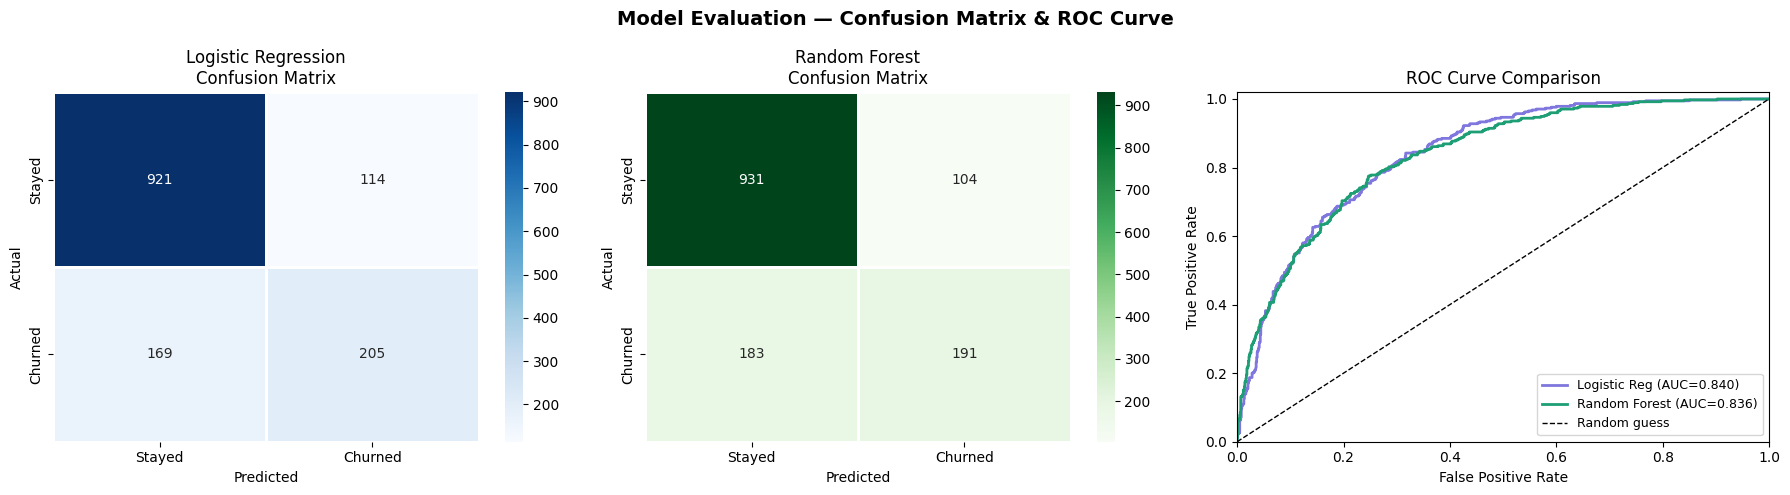

Saved: plot_confusion_roc.png


In [32]:
# ── CONFUSION MATRIX + ROC CURVE ───────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            ax=axes[0], linewidths=1,
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
axes[0].set_title(f'Logistic Regression\nConfusion Matrix', fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion matrix — Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            ax=axes[1], linewidths=1,
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
axes[1].set_title(f'Random Forest\nConfusion Matrix', fontsize=12)
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# ROC Curve — both models
for name, prob, color in [
    (f'Logistic Reg (AUC={lr_auc:.3f})', lr_pred_prob, '#7F77DD'),
    (f'Random Forest (AUC={rf_auc:.3f})', rf_pred_prob, '#1D9E75'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[2].plot(fpr, tpr, color=color, linewidth=2, label=name)

axes[2].plot([0,1], [0,1], 'k--', linewidth=1, label='Random guess')
axes[2].set_title('ROC Curve Comparison', fontsize=12)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=9)
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.02])

plt.suptitle('Model Evaluation — Confusion Matrix & ROC Curve',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_confusion_roc.png")

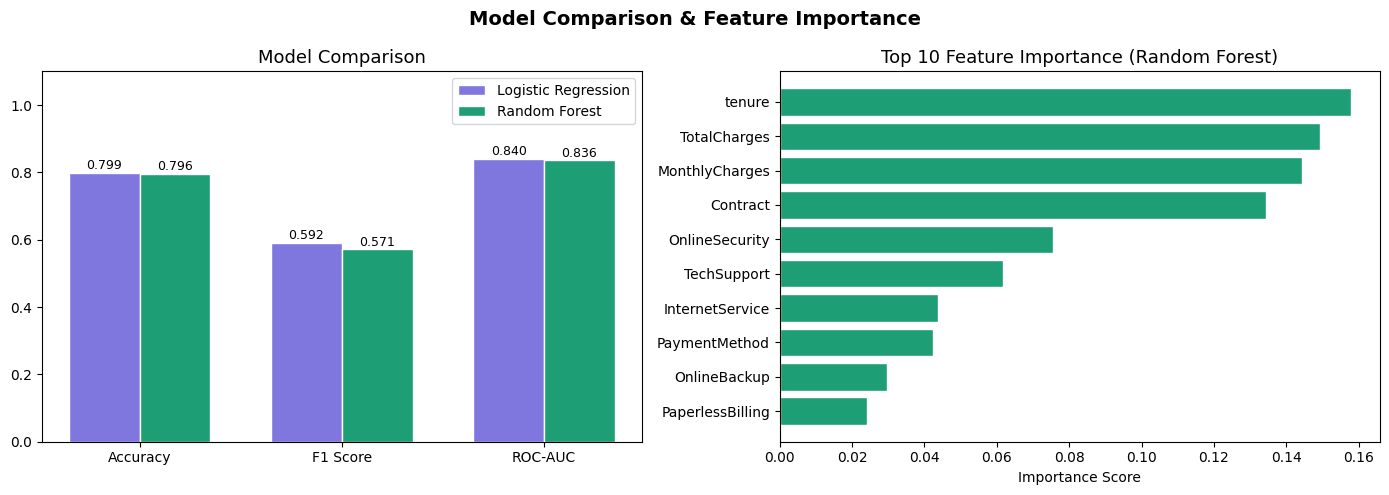

=== Final Comparison ===
Metric          Logistic Reg   Random Forest
--------------------------------------------
Accuracy              0.7991          0.7963
F1 Score              0.5916          0.5710
ROC-AUC               0.8403          0.8357

Step 3 complete! Both models trained and saved.
Ready for Step 4 — Interactive UI


In [33]:
# ── MODEL COMPARISON + FEATURE IMPORTANCE ──────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — metric comparison
metrics  = ['Accuracy', 'F1 Score', 'ROC-AUC']
lr_vals  = [lr_acc, lr_f1, lr_auc]
rf_vals  = [rf_acc, rf_f1, rf_auc]
x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, lr_vals, width,
                   label='Logistic Regression', color='#7F77DD',
                   edgecolor='white')
bars2 = axes[0].bar(x + width/2, rf_vals, width,
                   label='Random Forest', color='#1D9E75',
                   edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Model Comparison', fontsize=13)
axes[0].legend()
for bar in [*bars1, *bars2]:
    axes[0].text(bar.get_x() + bar.get_width()/2,
               bar.get_height() + 0.01,
               f'{bar.get_height():.3f}',
               ha='center', fontsize=9)

# Feature importance — Random Forest
top10 = importance_df.head(10)
axes[1].barh(top10['Feature'], top10['Importance'],
           color='#1D9E75', edgecolor='white')
axes[1].set_title('Top 10 Feature Importance (Random Forest)', fontsize=13)
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.suptitle('Model Comparison & Feature Importance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save all results for PDF report
model_results = {
    'Logistic Regression': {'Accuracy': lr_acc, 'F1': lr_f1, 'AUC': lr_auc},
    'Random Forest':       {'Accuracy': rf_acc, 'F1': rf_f1, 'AUC': rf_auc},
}

print("=== Final Comparison ===")
print(f"{'Metric':<12} {'Logistic Reg':>15} {'Random Forest':>15}")
print("-" * 44)
print(f"{'Accuracy':<12} {lr_acc:>15.4f} {rf_acc:>15.4f}")
print(f"{'F1 Score':<12} {lr_f1:>15.4f} {rf_f1:>15.4f}")
print(f"{'ROC-AUC':<12} {lr_auc:>15.4f} {rf_auc:>15.4f}")
print("\nStep 3 complete! Both models trained and saved.")
print("Ready for Step 4 — Interactive UI")